# **Log Analysis Training Model**

In [3]:
# Step 1:Imports

import os
import joblib
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC


In [4]:
import torch
torch.cuda.is_available()

True

In [5]:
# Step 2: File Reader

def read_syscalls_from_file(filepath):
    """Read system calls from a .GHC file"""
    syscalls = []
    with open(filepath, "r") as f:
        for line in f:
            syscalls.extend(line.strip().split())
    return syscalls


# Step 3: Data Collection

base_dir = "/kaggle/input/adfa-wd/Full_Process_Traces"
train_normal_dir = os.path.join(base_dir, "Full_Trace_Training_Data")
val_normal_dir   = os.path.join(base_dir, "Full_Trace_Validation_Data")
attack_dir       = os.path.join(base_dir, "Full_Trace_Attack_Data")

normal_files, attack_files = [], []

for folder in [train_normal_dir, val_normal_dir]:
    for root, _, files in os.walk(folder):
        for file in files:
            if file.endswith(".GHC"):
                normal_files.append(os.path.join(root, file))

for root, _, files in os.walk(attack_dir):
    for file in files:
        if file.endswith(".GHC"):
            attack_files.append(os.path.join(root, file))

print(f"Normal files: {len(normal_files)}, Attack files: {len(attack_files)}")

Normal files: 2182, Attack files: 5542


In [6]:
# Step 4: Encode Syscalls /build vocabulary
all_calls = set()
for file in normal_files + attack_files:
    all_calls.update(read_syscalls_from_file(file))

call_to_int = {call: idx for idx, call in enumerate(sorted(all_calls))}
print("Total unique calls mapped:", len(call_to_int))

def encode_file(filepath):
    calls = read_syscalls_from_file(filepath)
    return " ".join(str(call_to_int[c]) for c in calls if c in call_to_int)

Total unique calls mapped: 1309


In [7]:
print(call_to_int) # see the whole dict
# print(type(call_to_int))   
# print(list(call_to_int.values())[:20])  # first 20 values


{'comctl32.dll+0x10dad': 0, 'comctl32.dll+0x10e6d': 1, 'comctl32.dll+0x10e8c': 2, 'comctl32.dll+0x11036': 3, 'comctl32.dll+0x1105d': 4, 'comctl32.dll+0x111db': 5, 'comctl32.dll+0x11268': 6, 'comctl32.dll+0x11278': 7, 'comctl32.dll+0x11282': 8, 'comctl32.dll+0x11299': 9, 'comctl32.dll+0x112fa': 10, 'comctl32.dll+0x114a5': 11, 'comctl32.dll+0x114cc': 12, 'comctl32.dll+0x116a7': 13, 'comctl32.dll+0x11aeb': 14, 'comctl32.dll+0x11e3e': 15, 'comctl32.dll+0x12000': 16, 'comctl32.dll+0x12063': 17, 'comctl32.dll+0x151bf': 18, 'comctl32.dll+0x17c83': 19, 'comctl32.dll+0x17ce3': 20, 'comctl32.dll+0x17d27': 21, 'comctl32.dll+0x17d6a': 22, 'comctl32.dll+0x18017': 23, 'comctl32.dll+0x1808f': 24, 'comctl32.dll+0x180ce': 25, 'comctl32.dll+0x181a8': 26, 'comctl32.dll+0x181e2': 27, 'comctl32.dll+0x18273': 28, 'comctl32.dll+0x18676': 29, 'comctl32.dll+0x188a9': 30, 'comctl32.dll+0x18d0c': 31, 'comctl32.dll+0x19325': 32, 'comctl32.dll+0x195d6': 33, 'comctl32.dll+0x1a30c': 34, 'comctl32.dll+0x1a3de': 35, '

In [8]:
print(call_to_int.get('comctl32.dll+0x10dad')) 

0


In [9]:
# Step 5: Build Dataset

all_encoded_texts, labels = [], []

for f in normal_files:
    all_encoded_texts.append(encode_file(f))
    labels.append(0)

for f in attack_files:
    all_encoded_texts.append(encode_file(f))
    labels.append(1)

print(f"Total samples: {len(all_encoded_texts)}")

Total samples: 7724


In [10]:
all_encoded_texts[:1]

['938 942 927 934 935 697 695 693 29 30 18 681 934 935 697 695 693 29 30 18 681 934 935 697 695 693 29 30 18 681 934 935 697 695 693 29 30 18 681 934 935 697 695 693 29 30 18 681 934 935 697 695 693 29 30 18 681 934 935 697 695 693 29 30 18 681 934 935 697 695 693 29 30 18 681 934 935 697 695 693 29 30 18 681 690 681 681 681 681 681 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 455 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1000 1001 1003 1002 681 1

In [11]:
print(labels[:2])
print(labels[len(labels)-10:len(labels)])

[0, 0]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [12]:
# Step 6: Train/Test Split

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(all_encoded_texts)
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42,stratify=labels)

In [13]:
print("Shape of X:", X.shape)

print(X[1].toarray())# feature vector for the first file

print(X[1].toarray().shape)


Shape of X: (7724, 1299)
[[ 0  0  0 ...  3 11 92]]
(1, 1299)


In [14]:
# Step 7: Train Multiple Models Separately

classifiers = {
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=10000, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, clf in classifiers.items():
    print(f"\nTraining {name}...")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    
    # Save each model separately
    joblib.dump(clf, f"{name.replace(' ', '_').lower()}.pkl")

# Save vectorizer + call mapping (common for all)
joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(call_to_int, "call_to_int.pkl")




Training Random Forest...
Accuracy: 0.9314
              precision    recall  f1-score   support

           0       0.89      0.86      0.88       436
           1       0.95      0.96      0.95      1109

    accuracy                           0.93      1545
   macro avg       0.92      0.91      0.91      1545
weighted avg       0.93      0.93      0.93      1545


Training Logistic Regression...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8744
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       436
           1       0.93      0.90      0.91      1109

    accuracy                           0.87      1545
   macro avg       0.84      0.86      0.85      1545
weighted avg       0.88      0.87      0.88      1545


Training Gradient Boosting...
Accuracy: 0.9113
              precision    recall  f1-score   support

           0       0.94      0.73      0.82       436
           1       0.90      0.98      0.94      1109

    accuracy                           0.91      1545
   macro avg       0.92      0.86      0.88      1545
weighted avg       0.91      0.91      0.91      1545


Training XGBoost...
Accuracy: 0.9346
              precision    recall  f1-score   support

           0       0.92      0.85      0.88       436
           1       0.94      0.97      0.96      1109

    accuracy                           0.93      1545
   macro avg       0.93  

['call_to_int.pkl']

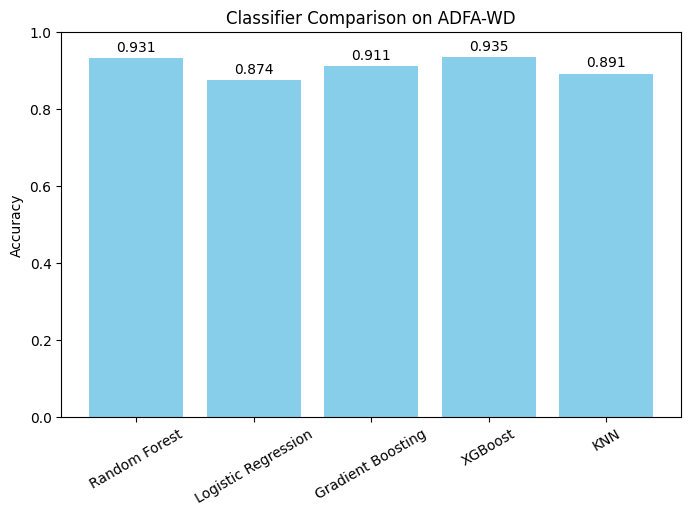

In [15]:
# Step 8: Plot Results

plt.figure(figsize=(8,5))
bars=plt.bar(results.keys(), results.values(), color="skyblue")
plt.ylabel("Accuracy")
plt.title("Classifier Comparison on ADFA-WD")
plt.xticks(rotation=30)
plt.ylim(0, 1)


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center", va="bottom"
    )

plt.show()

In [16]:
import joblib

def predict_file(filepath, model_name):
    """
    Predict whether a given .GHC file is Normal or Attack
    using a trained model of your choice.
    
    model_name: one of ["Random Forest", "Logistic Regression", "Gradient Boosting", "Naive Bayes", "KNN"]
    """
    # Load shared objects
    vectorizer = joblib.load("vectorizer.pkl")
    call_to_int = joblib.load("call_to_int.pkl")
    
    # Load selected model
    model_file = f"{model_name.replace(' ', '_').lower()}.pkl"
    clf = joblib.load(model_file)
    
    # Read and encode file
    calls = read_syscalls_from_file(filepath)
    encoded = " ".join(str(call_to_int[c]) for c in calls if c in call_to_int)
    
    # Transform and predict
    X_new = vectorizer.transform([encoded])
    prediction = clf.predict(X_new)[0]
    
    return "Normal" if prediction == 0 else "Attack"


In [17]:
test_file="/kaggle/input/adfa-wd/Full_Process_Traces/Full_Trace_Validation_Data/Validation-Backdoored-Executable-Part1_948.GHC"
print(predict_file(test_file, "Random Forest"))
print(predict_file(test_file, "KNN"))
print(predict_file(test_file, "XGBoost"))
print(predict_file(test_file, "Gradient Boosting"))
print(predict_file(test_file, "Logistic Regression"))

Normal
Attack
Normal
Attack
Normal


In [18]:
test_file="/kaggle/input/testghcfile/pid_5924_proc.GHC"

print(predict_file(test_file, "Random Forest"))
print(predict_file(test_file, "KNN"))
print(predict_file(test_file, "XGBoost"))
print(predict_file(test_file, "Gradient Boosting"))
print(predict_file(test_file, "Logistic Regression"))

Attack
Attack
Attack
Attack
Attack


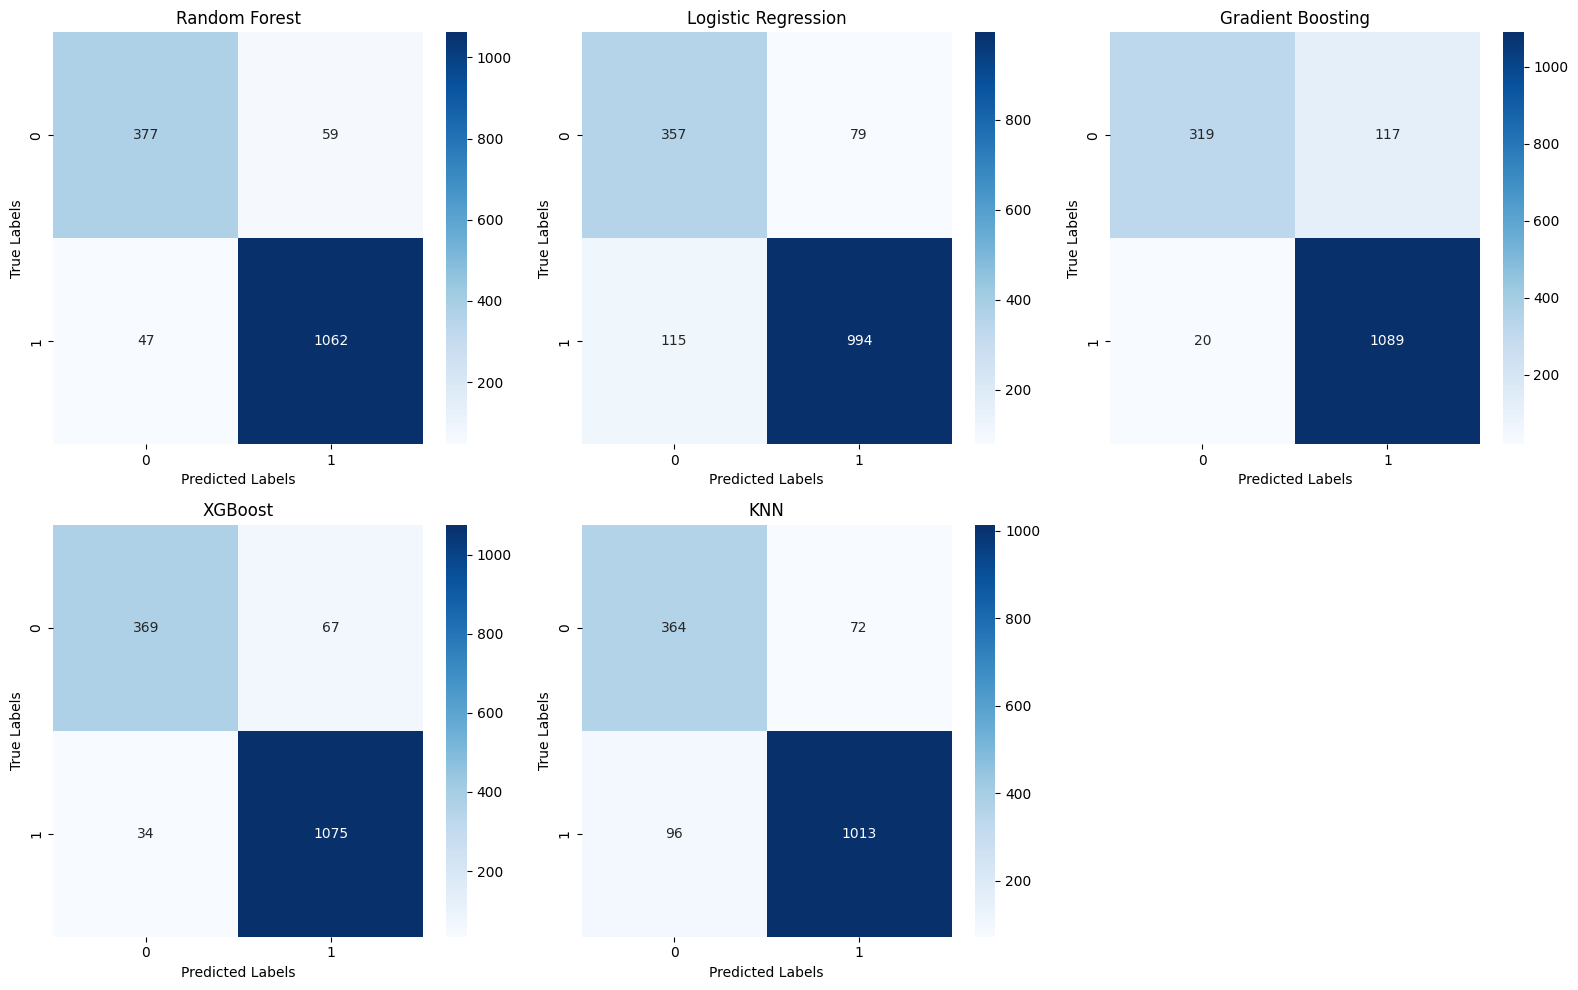

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, clf) in enumerate(classifiers.items()):
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"{name}")
    axes[i].set_xlabel("Predicted Labels")
    axes[i].set_ylabel("True Labels")

# Remove extra subplots if models < 6
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


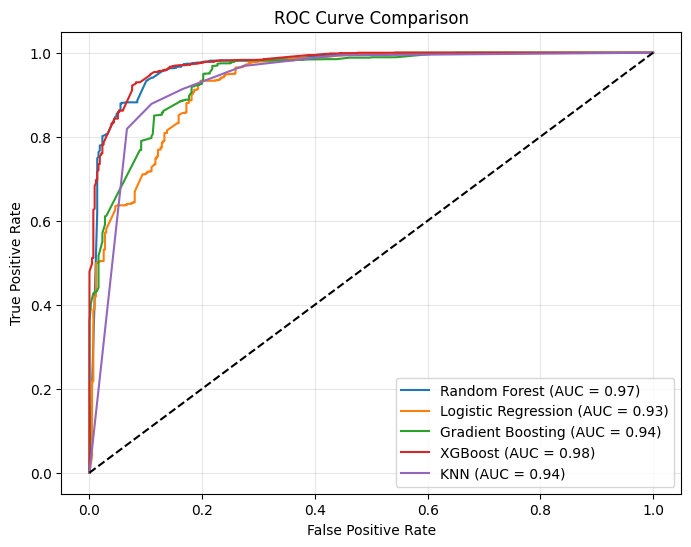

In [21]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for name, clf in classifiers.items():
    if hasattr(clf, "predict_proba"):  # not all models have this
        y_proba = clf.predict_proba(X_test)[:, 1]
    else:
        continue  # skip models that don't output probability
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


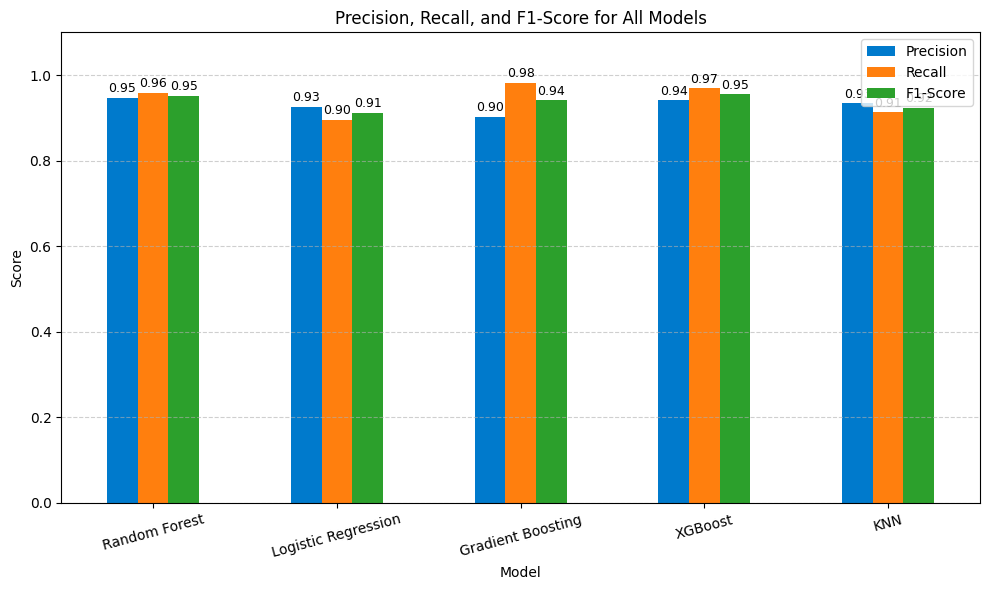

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# --- Compute metrics for each model ---
metrics_summary = {"Model": [], "Precision": [], "Recall": [], "F1-Score": []}

for name, clf in classifiers.items():
    y_pred = clf.predict(X_test)
    metrics_summary["Model"].append(name)
    metrics_summary["Precision"].append(round(precision_score(y_test, y_pred), 3))
    metrics_summary["Recall"].append(round(recall_score(y_test, y_pred), 3))
    metrics_summary["F1-Score"].append(round(f1_score(y_test, y_pred), 3))

df_metrics = pd.DataFrame(metrics_summary)
df_metrics.set_index("Model", inplace=True)

# --- Plot grouped bar chart ---
ax = df_metrics.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#007acc", "#ff7f0e", "#2ca02c"],
    title="Precision, Recall, and F1-Score for All Models"
)

plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# --- Add value labels on top of each bar ---
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", fontsize=9, padding=2)

plt.tight_layout()
plt.show()
